# SMS Spam Collection — Classificação binária (spam vs. ham)

Notebook do domínio **SMS Spam** do Trabalho A2 de Data Science.

**Classe positiva do domínio:** `spam` (a pergunta que o modelo responde é *"esta mensagem é spam?"*).

Este notebook cobre a Parte 2 do trabalho (item vi: comparação de pelo menos 3 algoritmos) e aplica o programa reutilizável da Parte 1 (histograma + pontos de corte) ao melhor modelo deste domínio (item ix).

Fonte dos dados: SMS Spam Collection (Almeida & Hidalgo), UCI Machine Learning Repository.

## 1. Carregamento dos dados e definição da classe positiva

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("SMSSpamCollection.csv")
df["target"] = (df["label"] == "spam").astype(int)
df.head()

,label,text,target
0,ham,I've been searching for the right words to tha...,0
1,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
2,ham,"Nah I don't think he goes to usf, he lives aro...",0
3,ham,Even my brother is not like to speak with me. ...,0
4,ham,I HAVE A DATE ON SUNDAY WITH WILL!!,0


## 2. Verificação do balanceamento (item iii)

Contagem e percentual de instâncias de cada classe.

In [2]:
contagem = df["target"].value_counts().sort_index()
percentual = (contagem / contagem.sum() * 100).round(2)
pd.DataFrame({"qtd": contagem, "%": percentual})

,qtd,%
target,,
0,4822,86.6
1,746,13.4


O dataset é desbalanceado (~13% spam). Isso já indica que acurácia isolada não é uma boa métrica
principal — vamos priorizar F1 e AUC-PR na comparação de algoritmos e na avaliação final.

## 3. Separação treino / validação / teste (item iv)

60% treino / 20% validação / 20% teste, estratificado pela classe. O ajuste de hiperparâmetros
(seção 5) usa validação cruzada dentro do treino; a escolha do melhor algoritmo usa o conjunto de
**validação**; o conjunto de **teste** fica reservado só para a avaliação final (seção 6).

In [3]:
from sklearn.model_selection import train_test_split

X_train_txt, X_temp_txt, y_train, y_temp = train_test_split(
    df["text"].values, df["target"].values, test_size=0.4, stratify=df["target"].values, random_state=42)
X_val_txt, X_test_txt, y_val, y_test = train_test_split(
    X_temp_txt, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Treino={len(y_train)}  Validação={len(y_val)}  Teste={len(y_test)}")
print(f"Proporção de spam -> treino={y_train.mean():.3f}  val={y_val.mean():.3f}  teste={y_test.mean():.3f}")

Treino=3340  Validação=1114  Teste=1114
Proporção de spam -> treino=0.134  val=0.135  teste=0.134


## 4. Representação TF-IDF (item v)

O `fit_transform` roda só no treino; validação e teste passam apenas por `transform`, para não
vazar informação do vocabulário/pesos IDF.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)
X_train = vectorizer.fit_transform(X_train_txt).toarray()
X_val = vectorizer.transform(X_val_txt).toarray()
X_test = vectorizer.transform(X_test_txt).toarray()
feature_names = vectorizer.get_feature_names_out()
X_train.shape

(3340, 3000)

## 5. Comparação de pelo menos 3 algoritmos (item vi)

Três algoritmos de naturezas diferentes: Regressão Logística (linear), Random Forest (ensemble de
árvores) e Hist Gradient Boosting (boosting). Cada um é ajustado por `GridSearchCV` com validação
cruzada (cv=3) dentro do treino, otimizando **AUC-PR** — métrica-alvo escolhida por ser mais
informativa que acurácia num problema desbalanceado. O melhor algoritmo geral é escolhido pelo
desempenho no conjunto de **validação**.

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

grids = {
    "Regressão Logística": (LogisticRegression(max_iter=1000, random_state=42),
                             {"C": [0.1, 1, 10], "class_weight": [None, "balanced"]}),
    "Random Forest": (RandomForestClassifier(random_state=42, n_jobs=1),
                       {"n_estimators": [150], "max_depth": [None, 12], "class_weight": [None, "balanced"]}),
    "Hist Gradient Boosting": (HistGradientBoostingClassifier(random_state=42),
                                {"max_iter": [100], "max_depth": [None, 10], "learning_rate": [0.1]}),
}

linhas = []
modelos_ajustados = {}
for nome, (estimador, grade) in grids.items():
    busca = GridSearchCV(estimador, grade, scoring="average_precision", cv=3, n_jobs=1)
    busca.fit(X_train, y_train)
    melhor = busca.best_estimator_
    prob_val = melhor.predict_proba(X_val)[:, 1]
    linhas.append({
        "Algoritmo": nome,
        "Melhores hiperparâmetros": busca.best_params_,
        "AUC-PR (validação)": round(average_precision_score(y_val, prob_val), 4),
        "AUC-ROC (validação)": round(roc_auc_score(y_val, prob_val), 4),
    })
    modelos_ajustados[nome] = melhor

resultados = pd.DataFrame(linhas).sort_values("AUC-PR (validação)", ascending=False).reset_index(drop=True)
melhor_nome = resultados.iloc[0]["Algoritmo"]
melhor_modelo = modelos_ajustados[melhor_nome]
resultados

,Algoritmo,Melhores hiperparâmetros,AUC-PR (validação),AUC-ROC (validação)
0,Regressão Logística,"{'C': 10, 'class_weight': None}",0.9903,0.9978
1,Random Forest,"{'class_weight': None, 'max_depth': None, 'n_e...",0.9839,0.9961
2,Hist Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': None, 'max...",0.9604,0.9877


*(preencher aqui a leitura dos resultados com as próprias palavras da equipe)*

## 6. Avaliação dos 3 algoritmos e do melhor modelo no conjunto de teste (item vii)

Métricas completas (acurácia, precisão, recall, F1, AUC-ROC, AUC-PR, matriz de confusão) para os
3 algoritmos, calculadas na validação, com threshold explícito de 0,50. O melhor modelo
(`{melhor_nome}`) é então avaliado no conjunto de **teste**, reservado até aqui.

In [6]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_curve, precision_recall_curve, auc)

def metricas_completas(modelos, X, y, limiar=0.5):
    linhas = []
    for nome, modelo in modelos.items():
        prob = modelo.predict_proba(X)[:, 1]
        pred = (prob >= limiar).astype(int)
        linhas.append({
            "Algoritmo": nome, "Threshold": limiar,
            "Acurácia": round(accuracy_score(y, pred), 4),
            "Precisão": round(precision_score(y, pred, zero_division=0), 4),
            "Recall": round(recall_score(y, pred, zero_division=0), 4),
            "F1": round(f1_score(y, pred, zero_division=0), 4),
            "AUC-ROC": round(roc_auc_score(y, prob), 4),
            "AUC-PR (Average Precision)": round(average_precision_score(y, prob), 4),
            "Matriz de confusão [[TN FP][FN TP]]": confusion_matrix(y, pred).tolist(),
        })
    return pd.DataFrame(linhas)

tabela_val_3algoritmos = metricas_completas(modelos_ajustados, X_val, y_val)
tabela_val_3algoritmos

,Algoritmo,Threshold,Acurácia,Precisão,Recall,F1,AUC-ROC,AUC-PR (Average Precision),Matriz de confusão [[TN FP][FN TP]]
0,Regressão Logística,0.5,0.9874,1.0000,0.9067,0.9510,0.9978,0.9903,"[[964, 0], [14, 136]]"
1,Random Forest,0.5,0.9776,1.0000,0.8333,0.9091,0.9961,0.9839,"[[964, 0], [25, 125]]"
2,Hist Gradient Boosting,0.5,0.9803,0.9923,0.8600,0.9214,0.9877,0.9604,"[[963, 1], [21, 129]]"


In [7]:
proba_test = melhor_modelo.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

print(f"Melhor modelo: {melhor_nome}")
print(f"Acurácia: {accuracy_score(y_test, pred_test):.4f}")
print(f"Precisão: {precision_score(y_test, pred_test):.4f}")
print(f"Recall: {recall_score(y_test, pred_test):.4f}")
print(f"F1: {f1_score(y_test, pred_test):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, proba_test):.4f}")
print(f"AUC-PR (Average Precision): {average_precision_score(y_test, proba_test):.4f}")
print("Matriz de confusão [[TN FP][FN TP]]:")
print(confusion_matrix(y_test, pred_test))

Melhor modelo: Regressão Logística
Acurácia: 0.9820
Precisão: 0.9924
Recall: 0.8725
F1: 0.9286
AUC-ROC: 0.9941
AUC-PR (Average Precision): 0.9818
Matriz de confusão [[TN FP][FN TP]]:
[[964   1]
 [ 19 130]]


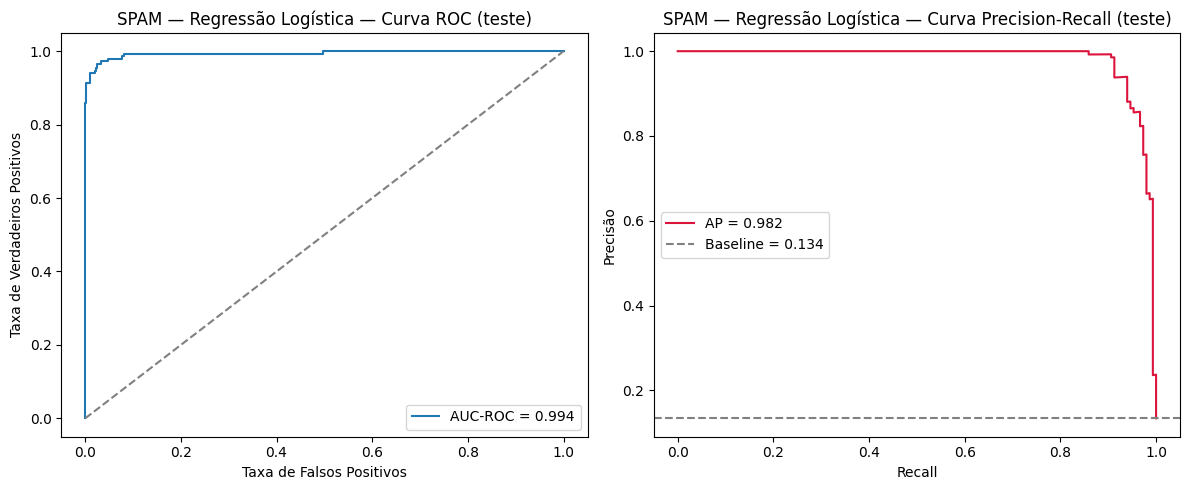

In [8]:
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, proba_test)
prec, rec, _ = precision_recall_curve(y_test, proba_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label=f"AUC-ROC = {auc(fpr, tpr):.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("Taxa de Falsos Positivos"); axes[0].set_ylabel("Taxa de Verdadeiros Positivos")
axes[0].set_title(f"SPAM — {melhor_nome} — Curva ROC (teste)"); axes[0].legend()

axes[1].plot(rec, prec, color="crimson", label=f"AP = {average_precision_score(y_test, proba_test):.3f}")
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label=f"Baseline = {y_test.mean():.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precisão")
axes[1].set_title(f"SPAM — {melhor_nome} — Curva Precision-Recall (teste)"); axes[1].legend()
fig.tight_layout()
plt.show()

**Como as curvas são construídas:** a curva ROC varia o limiar de decisão de 0 a 1 e, em cada ponto,
calcula a taxa de verdadeiros positivos e a taxa de falsos positivos; a área sob ela (AUC-ROC) mede a
capacidade de separação das classes independente do limiar. A curva Precision-Recall plota precisão
vs. recall a cada limiar. A área sob a PR reportada aqui é a **Average Precision (AP)**
(`average_precision_score`), distinta da integração trapezoidal simples sobre os pontos da curva.

*(preencher aqui a leitura dos números com as próprias palavras da equipe)*

## 7. SHAP — explicação do melhor modelo (item viii)

Explicação sobre a saída de probabilidade da classe spam, numa amostra de 300 mensagens do teste.

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


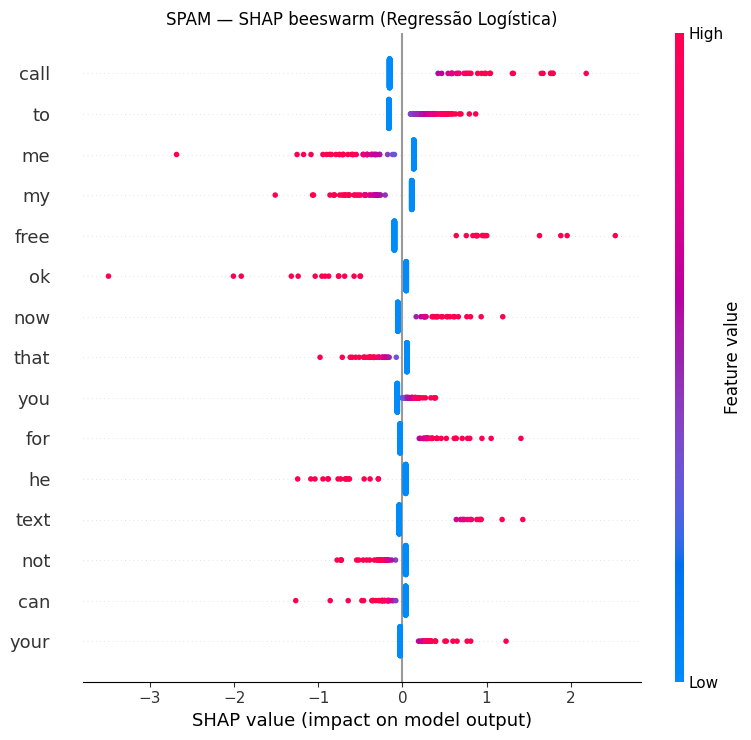

In [9]:
import shap

idx_amostra = np.random.default_rng(42).choice(len(X_test), size=min(300, len(X_test)), replace=False)
amostra = X_test[idx_amostra]

if melhor_nome == "Regressão Logística":
    fundo = shap.sample(amostra, min(200, amostra.shape[0]))
    explainer = shap.LinearExplainer(melhor_modelo, fundo)
    valores_shap = explainer.shap_values(amostra)
else:
    explainer = shap.TreeExplainer(melhor_modelo)
    valores_shap = explainer.shap_values(amostra)
    if isinstance(valores_shap, list):
        valores_shap = valores_shap[1]
    if valores_shap.ndim == 3:
        valores_shap = valores_shap[:, :, 1]

shap.summary_plot(valores_shap, amostra, feature_names=feature_names, max_display=15, show=False)
plt.title(f"SPAM — SHAP beeswarm ({melhor_nome})")
plt.tight_layout()
plt.show()

*(preencher aqui a leitura do gráfico SHAP com as próprias palavras da equipe)*

## 8. Programa da Parte 1 — histograma e faixas de decisão (reutilizável)

Função única, parametrizada por `y_real`, `y_prob`, `t1`, `t2` e `largura_intervalo` — funciona para
qualquer dataset/modelo que forneça rótulo real (0/1) e probabilidade da classe positiva.

In [10]:
def analisar_faixas_decisao(y_real, y_prob, largura_intervalo=10, t1=None, t2=None,
                             classe_positiva=1, titulo="Distribuição de Probabilidades"):
    y_real = np.asarray(y_real)
    y_prob = np.asarray(y_prob, dtype=float)
    prob_pct = y_prob * 100 if y_prob.max() <= 1.0 else y_prob

    n_faixas = int(round(100 / largura_intervalo))
    bordas = np.linspace(0, 100, n_faixas + 1)
    todas_contagens, _ = np.histogram(prob_pct, bins=bordas)
    positivos_mask = (y_real == classe_positiva)
    positivos_contagens, _ = np.histogram(prob_pct[positivos_mask], bins=bordas)

    total = len(prob_pct)
    todas_pct = todas_contagens / total * 100
    positivos_pct = positivos_contagens / total * 100

    fig, ax = plt.subplots(figsize=(10, 6))
    centros = (bordas[:-1] + bordas[1:]) / 2
    largura = largura_intervalo * 0.9
    ax.bar(centros, todas_pct, width=largura, color="steelblue", alpha=0.6, label="Todas as instâncias", edgecolor="black")
    ax.bar(centros, positivos_pct, width=largura * 0.6, color="crimson", alpha=0.8,
           label=f"Instâncias com rótulo real = {classe_positiva}", edgecolor="black")
    ax.set_ylim(top=ax.get_ylim()[1] * 1.15)

    if t1 is not None:
        t1_pct = t1 * 100 if t1 <= 1.0 else t1
        ax.axvline(t1_pct, color="black", linestyle="--")
        ax.text(t1_pct, ax.get_ylim()[1] * 0.93, f" t1={t1_pct:.1f}% ", rotation=90, va="top",
                ha="left" if t1_pct < 50 else "right", fontsize=9,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1))
    if t2 is not None:
        t2_pct = t2 * 100 if t2 <= 1.0 else t2
        ax.axvline(t2_pct, color="black", linestyle="--")
        ax.text(t2_pct, ax.get_ylim()[1] * 0.93, f" t2={t2_pct:.1f}% ", rotation=90, va="top",
                ha="left" if t2_pct < 50 else "right", fontsize=9,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1))

    ax.set_xlabel("Probabilidade estimada da classe positiva (%)")
    ax.set_ylabel("Percentual de instâncias (%)")
    ax.set_title(titulo)
    ax.set_xlim(0, 100)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()

    tabela_faixas = None
    resumo_erros = None
    if t1 is not None and t2 is not None:
        t1_pct = t1 * 100 if t1 <= 1.0 else t1
        t2_pct = t2 * 100 if t2 <= 1.0 else t2
        faixa_neg = prob_pct < t1_pct
        faixa_manual = (prob_pct >= t1_pct) & (prob_pct < t2_pct)
        faixa_pos = prob_pct >= t2_pct

        linhas = []
        for nome, mascara in [("Negativa automática", faixa_neg), ("Análise manual", faixa_manual), ("Positiva automática", faixa_pos)]:
            n_faixa = int(mascara.sum())
            n_pos = int((mascara & positivos_mask).sum())
            n_neg = n_faixa - n_pos
            linhas.append({
                "Faixa": nome,
                f"% da população (n={total})": round(n_faixa / total * 100, 2),
                "Qtd positivos": n_pos,
                "% positivos na faixa": round(n_pos / n_faixa * 100, 2) if n_faixa else 0.0,
                "Qtd negativos": n_neg,
                "% negativos na faixa": round(n_neg / n_faixa * 100, 2) if n_faixa else 0.0,
            })
        tabela_faixas = pd.DataFrame(linhas)

        n_pos_total = int(positivos_mask.sum())
        n_neg_total = total - n_pos_total
        fn = int((positivos_mask & faixa_neg).sum())
        fp = int((~positivos_mask & faixa_pos).sum())
        resumo_erros = pd.DataFrame([{
            "Positivos → negativo automático (%)": round(fn / n_pos_total * 100, 2) if n_pos_total else 0.0,
            "Denominador (positivos reais)": n_pos_total,
            "Negativos → positivo automático (%)": round(fp / n_neg_total * 100, 2) if n_neg_total else 0.0,
            "Denominador (negativos reais)": n_neg_total,
        }])

    return fig, tabela_faixas, resumo_erros

## 9. Escolha dos pontos de corte na validação e aplicação ao teste (item ix)

`t1` e `t2` são definidos como quantis das probabilidades estimadas no conjunto de **validação** e
aplicados sem novos ajustes ao conjunto de **teste**.

t1=0.0108  t2=0.8073


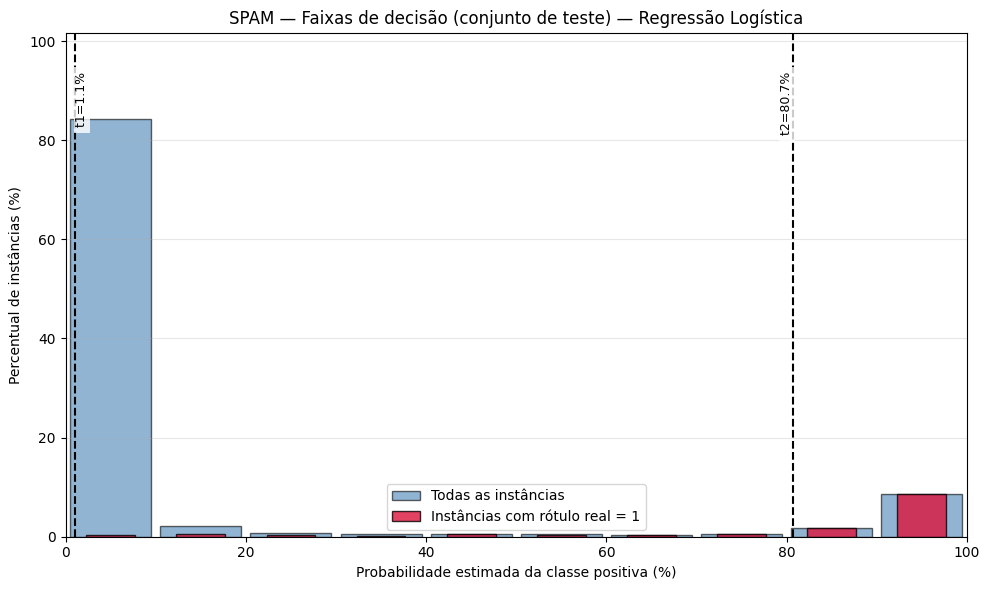

In [11]:
prob_val_melhor = melhor_modelo.predict_proba(X_val)[:, 1]
t1, t2 = np.quantile(prob_val_melhor, [0.5, 0.9])
print(f"t1={t1:.4f}  t2={t2:.4f}")

fig, tabela_faixas, resumo_erros = analisar_faixas_decisao(
    y_test, proba_test, largura_intervalo=10, t1=t1, t2=t2,
    titulo=f"SPAM — Faixas de decisão (conjunto de teste) — {melhor_nome}")
plt.show()

In [12]:
print(tabela_faixas.to_string(index=False))

              Faixa  % da população (n=1114)  Qtd positivos  % positivos na faixa  Qtd negativos  % negativos na faixa
Negativa automática                    50.99              1                  0.18            567                 99.82
     Análise manual                    38.60             32                  7.44            398                 92.56
Positiva automática                    10.41            116                100.00              0                  0.00


In [13]:
print(resumo_erros.to_string(index=False))

 Positivos → negativo automático (%)  Denominador (positivos reais)  Negativos → positivo automático (%)  Denominador (negativos reais)
                                0.67                            149                                  0.0                            965


*(preencher aqui a política de triagem e a justificativa da equipe para t1/t2)*